<a href="https://colab.research.google.com/github/pidot420/pidot420/blob/main/datasetTutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
lego_sets = pd.read_csv("/content/drive/MyDrive/lego_dataset/lego_sets.csv")

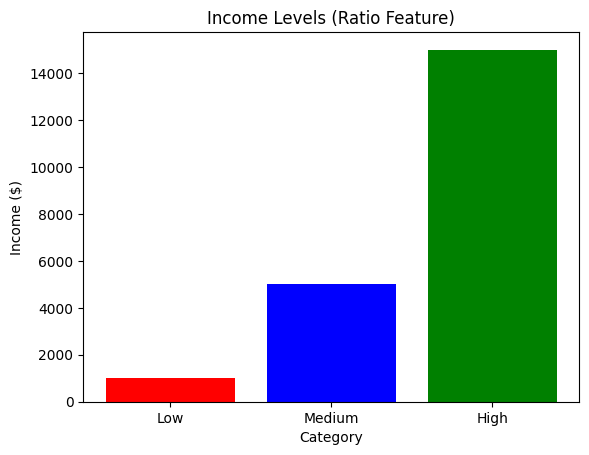

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

categories = ["Low", "Medium", "High"]
incomes = [1000, 5000, 15000]

plt.bar(categories, incomes, color=["red", "blue", "green"])

plt.xlabel("Category")
plt.ylabel("Income ($)")
plt.title("Income Levels (Ratio Feature)")

plt.show()

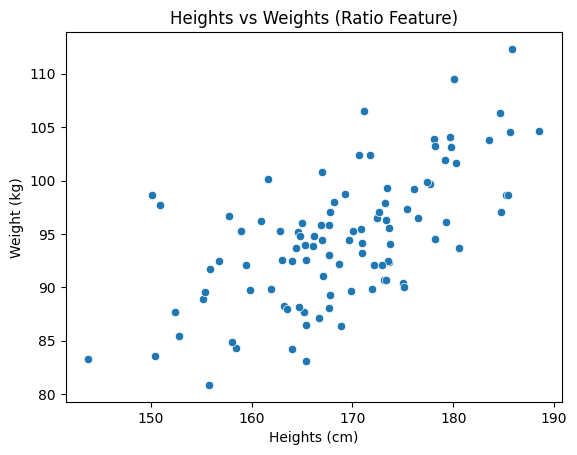

In [ ]:
import seaborn as sns
import pandas as pd

np.random.seed(42)
heights = np.random.normal(170, 10, 100)
weights = heights * 0.5 + np.random.normal(10, 5, 100)

df = pd.DataFrame({"Heights (cm)": heights, "Weight (kg)": weights})

sns.scatterplot(x = "Heights (cm)", y = "Weight (kg)", data=df)
plt.title("Heights vs Weights (Ratio Feature)")
plt.show()

In [ ]:
lego_sets.isnull().sum()

,0
set_id,0
name,0
year,0
theme,0
subtheme,3556
themeGroup,2
category,0
pieces,3924
minifigs,10058
agerange_min,11670


In [3]:
train = pd.read_csv("/content/drive/MyDrive/train.csv")

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# select four features for training
selected_features = ['Age', 'Fare', 'SibSp', 'Parch']
x = train[selected_features]
y = train['Survived']


# split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# create a column transformer
numerical_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='median')), # handle missing values
    ('scaler', StandardScaler())

])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, selected_features)
    ])
# create a pipeline with the preprocessor and a Logistic regression Model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# train the model
model.fit(x_train, y_train)

# make predictions on the test set
y_pred = model.predict(x_test)

# evaluate the model
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy:", {accuracy})

Accuracy: {0.6815642458100558}


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression

# select four features for training
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']
nominal_features = ['Embarked', 'Sex', 'Cabin']
ordinal_features = ['Pclass']

# create pipeline
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])

# create a Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('nom', nominal_pipeline, nominal_features),
        ('ord', ordinal_pipeline, ordinal_features)
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())  # replace with your desired model
])

x = train[numerical_features + nominal_features + ordinal_features]
y = train['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# train the model
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy:", {accuracy})

Accuracy: {0.8212290502793296}


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif

# select four features for training
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']
nominal_features = ['Embarked', 'Sex', 'Cabin']
ordinal_features = ['Pclass']

# create pipeline
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])

# create a Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('nom', nominal_pipeline, nominal_features),
        ('ord', ordinal_pipeline, ordinal_features)
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(f_classif, k=100)),
    ('classifier', LogisticRegression())  # replace with your desired model
])

x = train[numerical_features + nominal_features + ordinal_features]
y = train['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# train the model
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy:", {accuracy})

Accuracy: {0.8100558659217877}


In [15]:
model.named_steps['preprocessor'].transform(x_train).shape

(712, 127)

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, chi2

# select four features for training
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']
nominal_features = ['Embarked', 'Sex', 'Cabin']
ordinal_features = ['Pclass']

# create pipeline
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('selector', SelectKBest(f_classif, k=4)),
    ('scaler', StandardScaler())
])

nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
    ('selector', SelectKBest(chi2, k=122))
])

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])

# create a Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('nom', nominal_pipeline, nominal_features),
        ('ord', ordinal_pipeline, ordinal_features)
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(f_classif, k=100)),
    ('classifier', LogisticRegression())  # replace with your desired model
])

x = train[numerical_features + nominal_features + ordinal_features]
y = train['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# train the model
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy:", {accuracy})

Accuracy: {0.8100558659217877}


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import f_classif, chi2, RFE

# select four features for training
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']
nominal_features = ['Embarked', 'Sex', 'Cabin']
ordinal_features = ['Pclass']

# create pipeline
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])

# create a Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('nom', nominal_pipeline, nominal_features),
        ('ord', ordinal_pipeline, ordinal_features)
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rfe', RFE(LogisticRegression(), n_features_to_select=100)),
    ('classifier', LogisticRegression())  # replace with your desired model
])

x = train[numerical_features + nominal_features + ordinal_features]
y = train['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# train the model
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy:", {accuracy})

Accuracy: {0.8100558659217877}


In [23]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [45]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   PassengerId         891 non-null    int64   
 1   Survived            891 non-null    int64   
 2   Pclass              891 non-null    int64   
 3   Name                891 non-null    object  
 4   Sex                 891 non-null    object  
 5   Age                 714 non-null    float64 
 6   SibSp               891 non-null    int64   
 7   Parch               891 non-null    int64   
 8   Ticket              891 non-null    object  
 9   Fare                891 non-null    float64 
 10  Cabin               204 non-null    object  
 11  Embarked            889 non-null    object  
 12  family_size         891 non-null    int64   
 13  is_alone            891 non-null    int64   
 14  Alone_Category      891 non-null    object  
 15  AgefareInteraction  714 non-null    floa

In [47]:
train['AgeCategory'] = pd.cut(train['Age'], bins=[0, 12, 18, 50, 100], labels=['Child', 'Teen', 'Adult', 'Senior'])
train['AgeSexGroup'] = train['AgeCategory'].astype(str) + '_' + train['Sex']

In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import f_classif, chi2, RFE

# select four features for training
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch', 'AgefareInteraction']
nominal_features = ['Embarked', 'Sex', 'Cabin', 'AgeSexGroup']
ordinal_features = ['Pclass']

# create pipeline
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])

# create a Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('nom', nominal_pipeline, nominal_features),
        ('ord', ordinal_pipeline, ordinal_features)
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rfe', RFE(LogisticRegression(), n_features_to_select=100)),
    ('classifier', LogisticRegression())  # replace with your desired model
])

x = train[numerical_features + nominal_features + ordinal_features]
y = train['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# train the model
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy} , n_features_to-select: {model.named_steps['rfe'].n_features_to_select}")

Accuracy: 0.8268156424581006 , n_features_to-select: 100
